In [30]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
df = pd.read_csv('data/diabetes.csv')

In [31]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
df = pd.read_csv("data/diabetes.csv", header=None, names=col_names)

In [32]:
X = df.drop(columns='label')
y = df["label"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=1, stratify=y)

In [34]:
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [35]:
y_hat = tree.predict(X_test)

In [36]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:", accuracy_score(y_test, y_hat))
# confusion matrix
cm = confusion_matrix(y_test, y_hat)
print(cm)

Accuracy: 0.73
[[54 11]
 [16 19]]


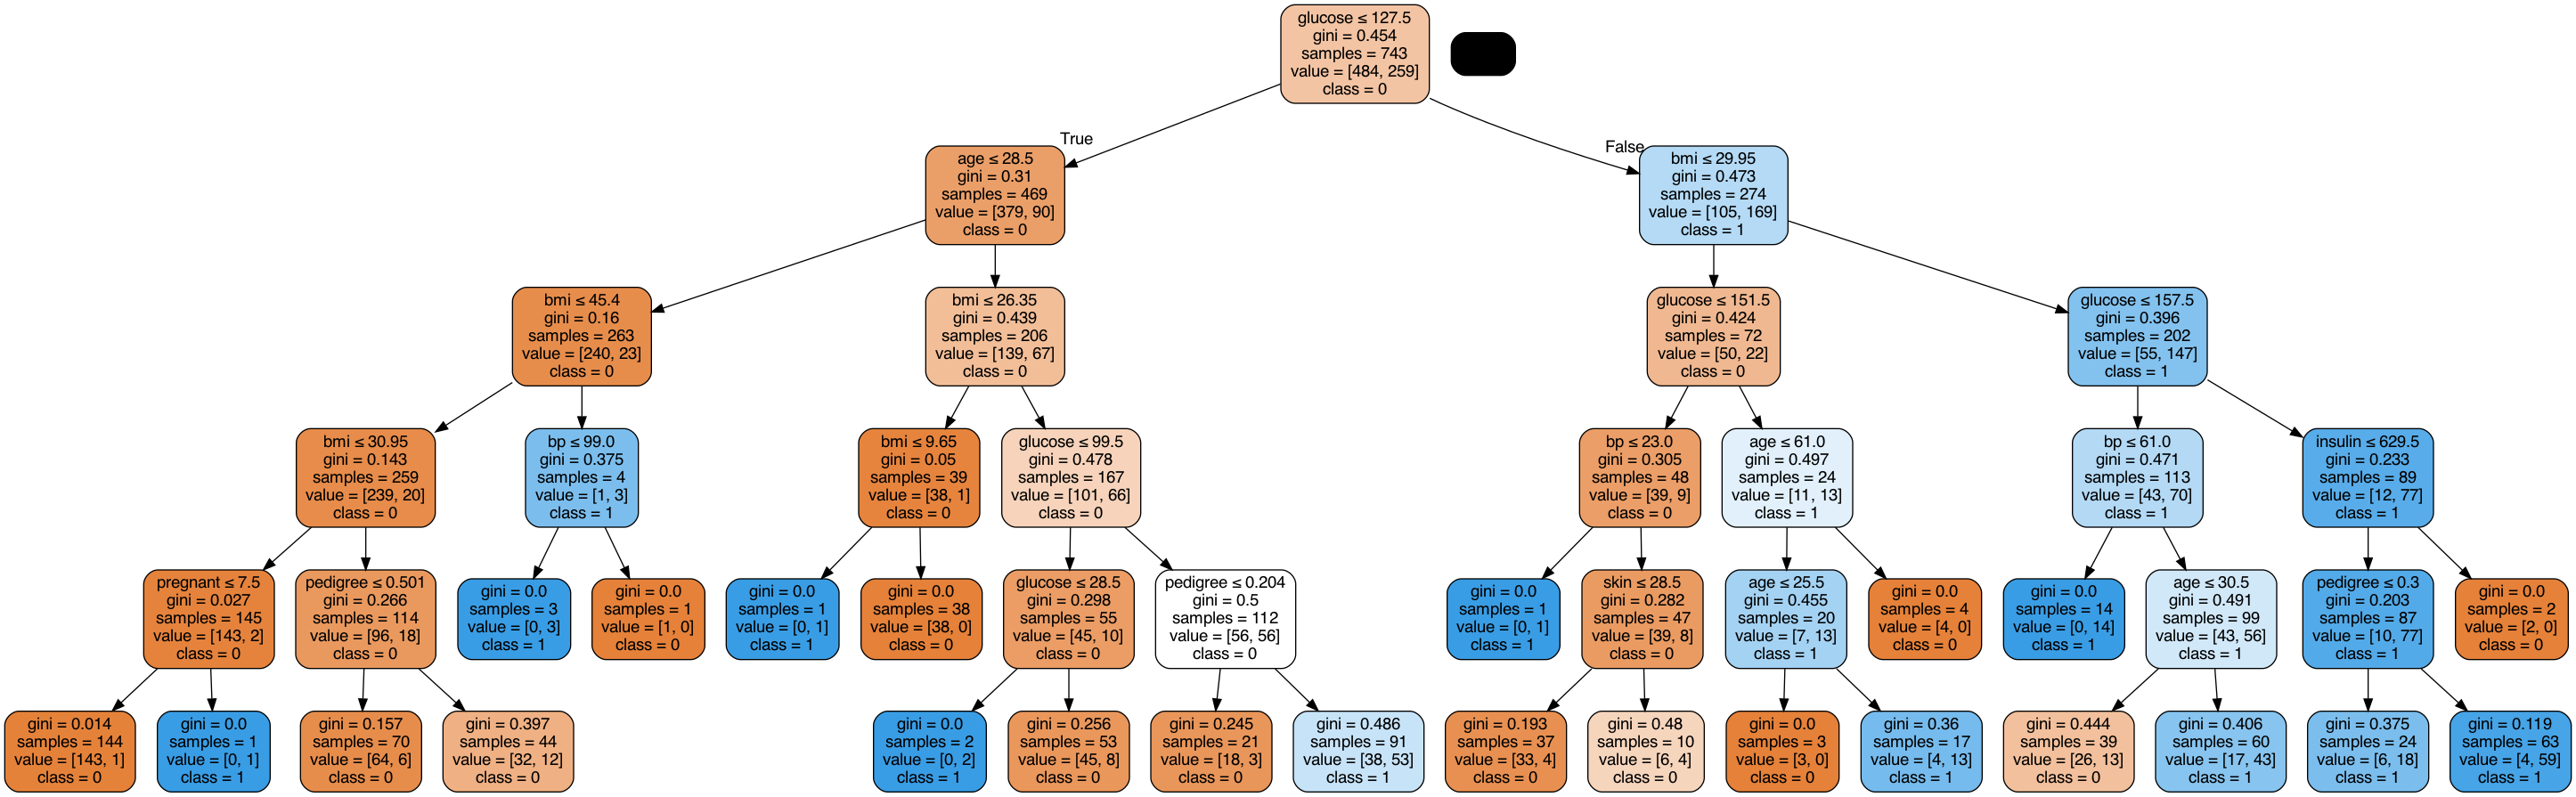

In [16]:
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus
feature_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age']
target_names = ['0','1']
dot_data = StringIO()
export_graphviz(tree, out_file=dot_data,
 filled=True, rounded=True,
 special_characters=True, feature_names = feature_names, 
 class_names = target_names)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
#graph.write_png('plots/iris.png')
Image(graph.create_png())